Consultando Dólar Americano (USD)
100 registros coletados
Consultando Euro (EUR)
100 registros coletados
Consultando Libra Esterlina (GBP)
100 registros coletados
Consultando Iene Japonês (JPY)
100 registros coletados
Consultando Peso Argentino (ARS)
Sem registros disponíveis no período
Arquivo gerado: dados_cotacoes/serie_USD.csv
Arquivo gerado: dados_cotacoes/serie_EUR.csv
Arquivo gerado: dados_cotacoes/serie_GBP.csv
Arquivo gerado: dados_cotacoes/serie_JPY.csv


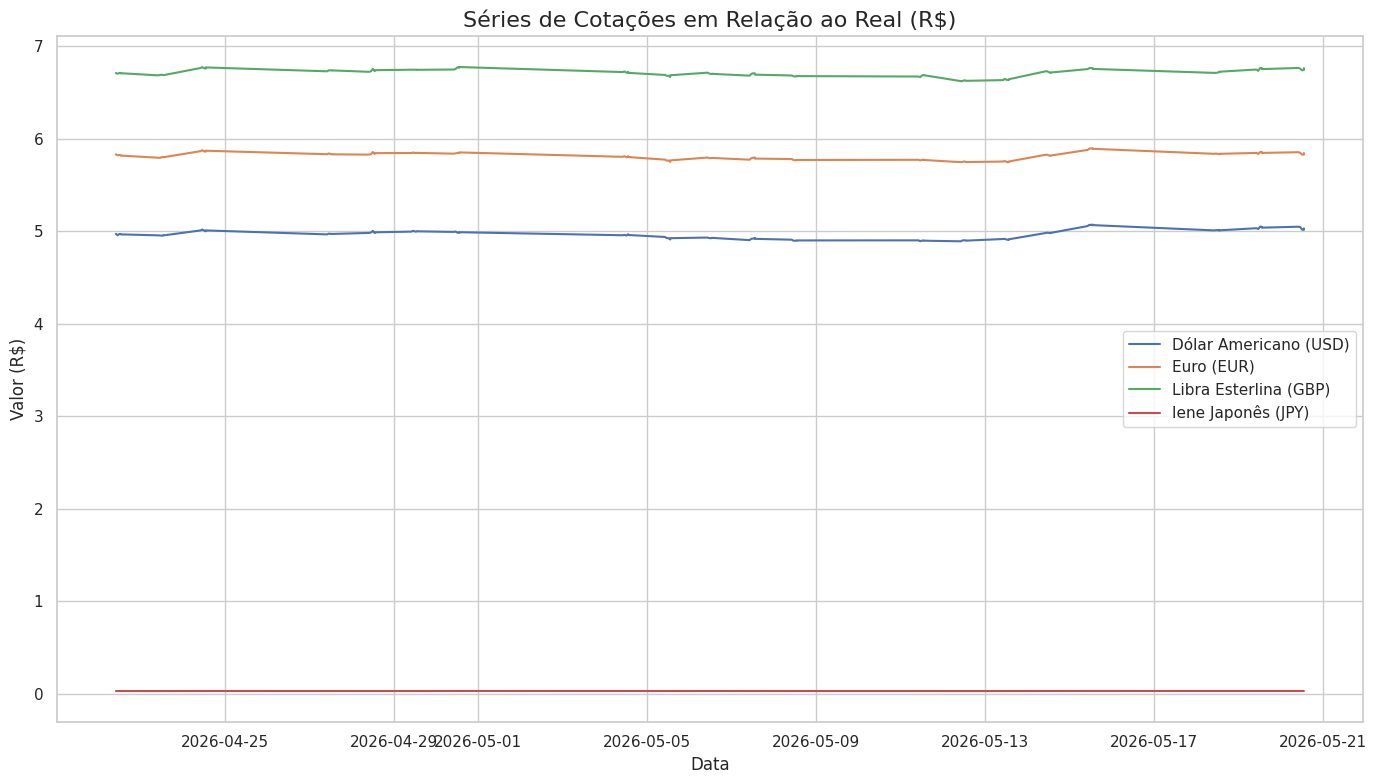

Visualização gerada: dados_cotacoes/serie_comparativa_moedas.png


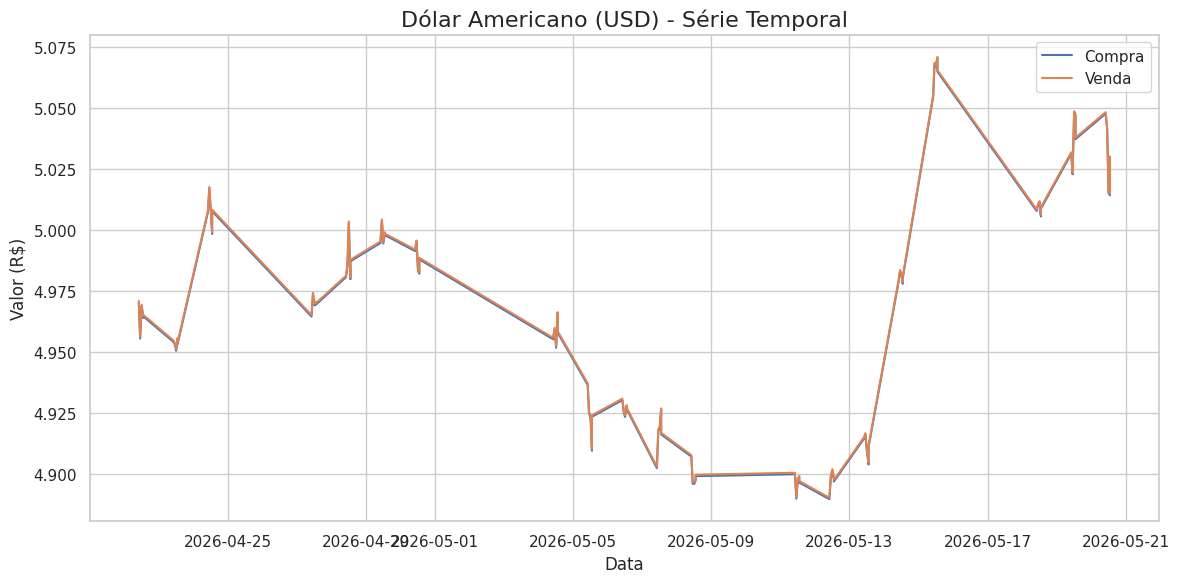

Visualização gerada: dados_cotacoes/serie_USD.png


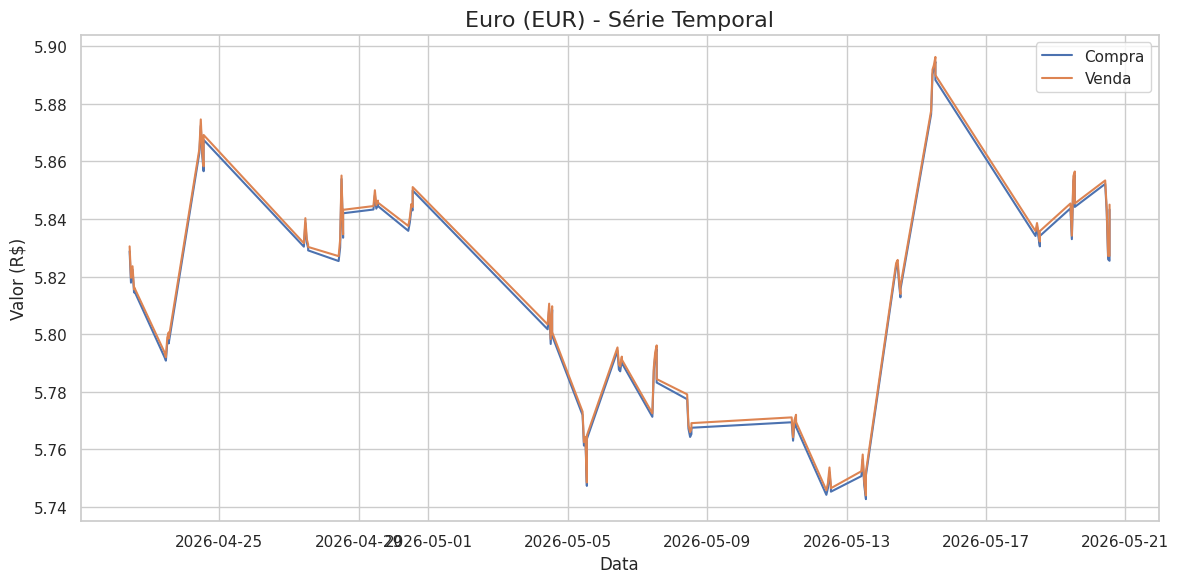

Visualização gerada: dados_cotacoes/serie_EUR.png


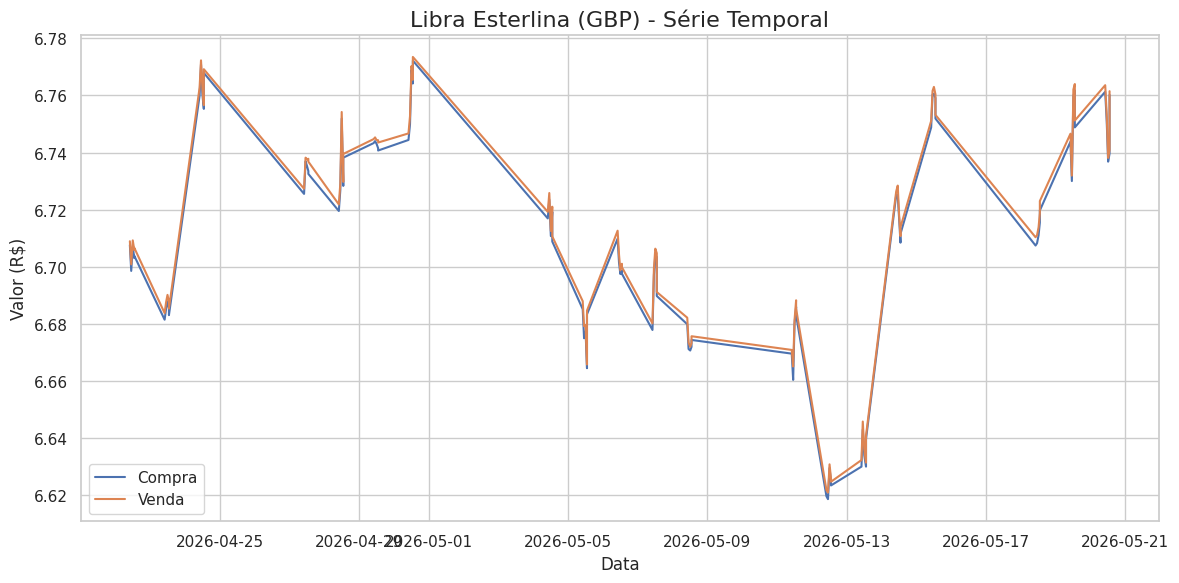

Visualização gerada: dados_cotacoes/serie_GBP.png


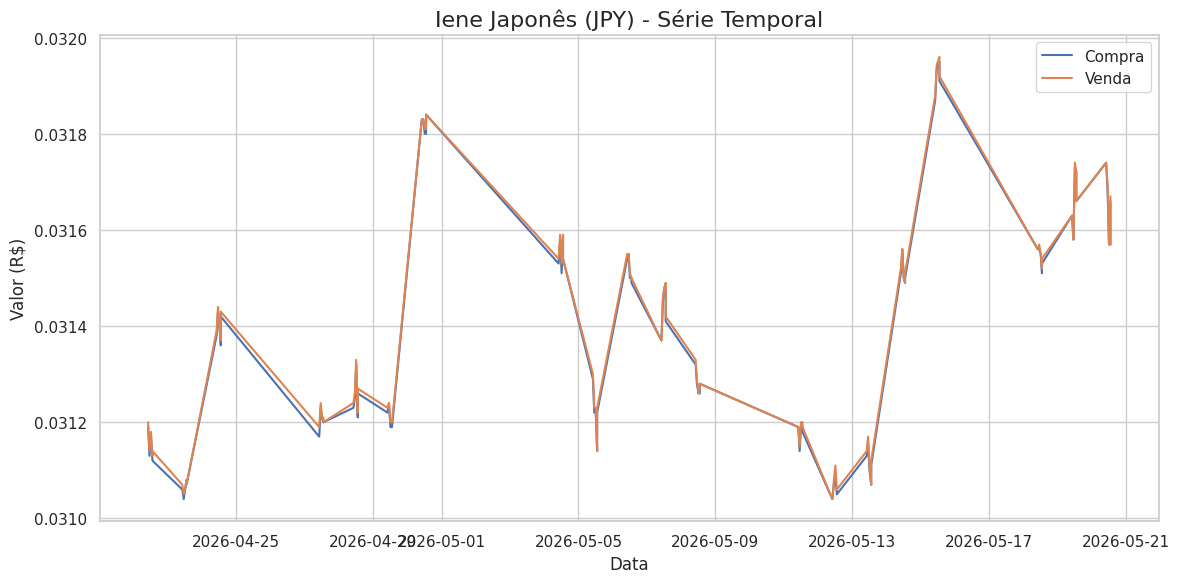

Visualização gerada: dados_cotacoes/serie_JPY.png


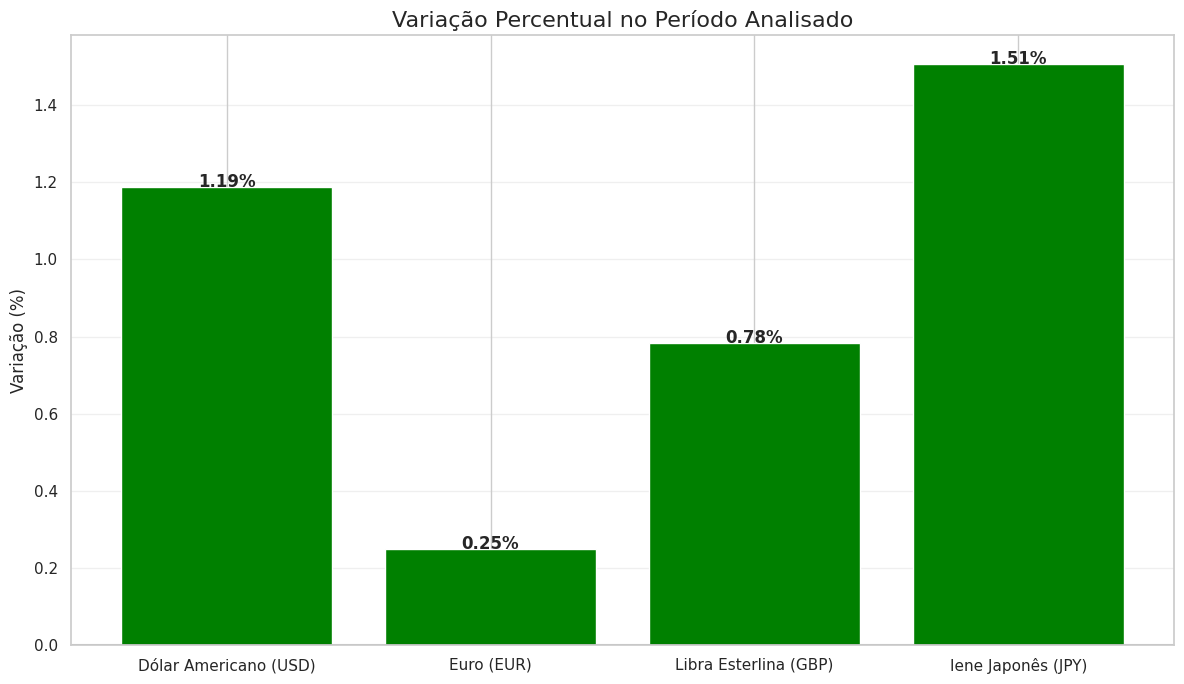

Visualização gerada: dados_cotacoes/variacao_percentual.png

Resumo estatístico

Dólar Americano (USD)
Período: 22/04/2026 até 20/05/2026
Mínimo: R$ 4.8905
Máximo: R$ 5.0708
Média: R$ 4.9665

Euro (EUR)
Período: 22/04/2026 até 20/05/2026
Mínimo: R$ 5.7440
Máximo: R$ 5.8963
Média: R$ 5.8131

Libra Esterlina (GBP)
Período: 22/04/2026 até 20/05/2026
Mínimo: R$ 6.6208
Máximo: R$ 6.7735
Média: R$ 6.7121

Iene Japonês (JPY)
Período: 22/04/2026 até 20/05/2026
Mínimo: R$ 0.0310
Máximo: R$ 0.0320
Média: R$ 0.0314


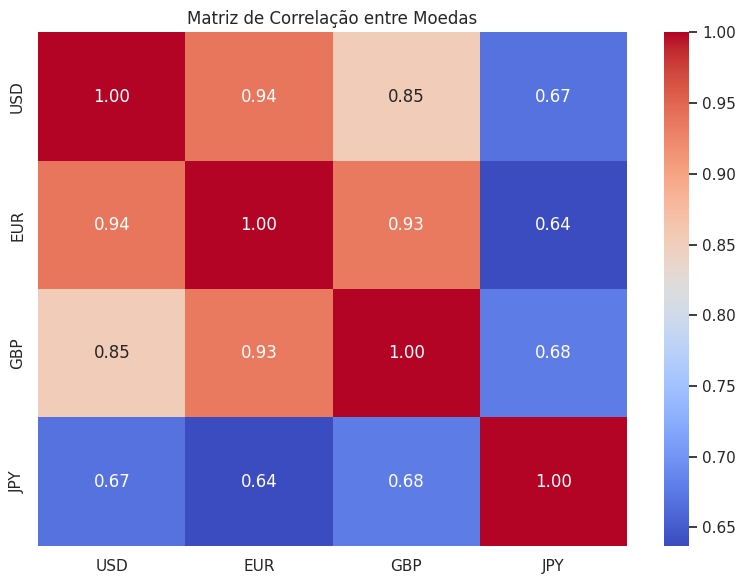

Análise concluída: dados_cotacoes/correlacao_moedas.png

Arquivo final gerado: relatorio_cotacoes_moedas.zip


In [4]:
# ============================
# Raspagem de Dados de Cotações de Moedas
# ============================

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os

plt.style.use('ggplot')
sns.set(style="whitegrid")

if not os.path.exists('dados_cotacoes'):
    os.makedirs('dados_cotacoes')

data_fim = datetime.now().strftime('%m-%d-%Y')
data_inicio = (datetime.now() - timedelta(days=30)).strftime('%m-%d-%Y')

moedas = {
    'USD': 'Dólar Americano',
    'EUR': 'Euro',
    'GBP': 'Libra Esterlina',
    'JPY': 'Iene Japonês',
    'ARS': 'Peso Argentino'
}

dados_cotacoes = {}

# Coleta de dados
for codigo, nome in moedas.items():
    print(f"Consultando {nome} ({codigo})")

    url = (
        "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        f"CotacaoMoedaPeriodo(moeda=@moeda,dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)"
        f"?@moeda='{codigo}'"
        f"&@dataInicial='{data_inicio}'"
        f"&@dataFinalCotacao='{data_fim}'"
        "&$top=100"
        "&$format=json"
    )

    response = requests.get(url)

    if response.status_code == 200:
        dados = response.json()

        if 'value' in dados and len(dados['value']) > 0:
            cotacoes = []

            for item in dados['value']:
                cotacoes.append({
                    'data': item['dataHoraCotacao'],
                    'cotacao_compra': item['cotacaoCompra'],
                    'cotacao_venda': item['cotacaoVenda']
                })

            dados_cotacoes[codigo] = {
                'nome': nome,
                'cotacoes': cotacoes
            }

            print(f"{len(cotacoes)} registros coletados")
        else:
            print("Sem registros disponíveis no período")
    else:
        print(f"Falha na requisição: {response.status_code}")


# Processamento e CSV
for codigo, dados in dados_cotacoes.items():
    df = pd.DataFrame(dados['cotacoes'])
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values('data')

    arquivo_csv = f'dados_cotacoes/serie_{codigo}.csv'
    df.to_csv(arquivo_csv, index=False, encoding='utf-8-sig')

    print(f"Arquivo gerado: {arquivo_csv}")


# Gráfico geral
plt.figure(figsize=(14, 8))

for codigo, dados in dados_cotacoes.items():
    df = pd.DataFrame(dados['cotacoes'])
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values('data')

    plt.plot(df['data'], df['cotacao_venda'], label=f"{dados['nome']} ({codigo})")

plt.title('Séries de Cotações em Relação ao Real (R$)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Valor (R$)')
plt.legend()
plt.grid(True)
plt.tight_layout()

arquivo_grafico = 'dados_cotacoes/serie_comparativa_moedas.png'
plt.savefig(arquivo_grafico, dpi=300)
plt.show()

print(f"Visualização gerada: {arquivo_grafico}")


# Gráficos individuais
for codigo, dados in dados_cotacoes.items():
    df = pd.DataFrame(dados['cotacoes'])
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values('data')

    plt.figure(figsize=(12, 6))

    plt.plot(df['data'], df['cotacao_compra'], label='Compra')
    plt.plot(df['data'], df['cotacao_venda'], label='Venda')

    plt.title(f'{dados["nome"]} ({codigo}) - Série Temporal', fontsize=16)
    plt.xlabel('Data')
    plt.ylabel('Valor (R$)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    arquivo_grafico = f'dados_cotacoes/serie_{codigo}.png'
    plt.savefig(arquivo_grafico, dpi=300)
    plt.show()

    print(f"Visualização gerada: {arquivo_grafico}")


# Variação percentual
variacoes = []
nomes = []

for codigo, dados in dados_cotacoes.items():
    df = pd.DataFrame(dados['cotacoes'])
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values('data')

    if len(df) >= 2:
        primeiro = df.iloc[0]['cotacao_venda']
        ultimo = df.iloc[-1]['cotacao_venda']
        variacao = ((ultimo - primeiro) / primeiro) * 100

        variacoes.append(variacao)
        nomes.append(f"{dados['nome']} ({codigo})")

cores = ['green' if v >= 0 else 'red' for v in variacoes]

plt.figure(figsize=(12, 7))
plt.bar(nomes, variacoes, color=cores)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

for i, v in enumerate(variacoes):
    plt.text(i, v, f"{v:.2f}%", ha='center', fontweight='bold')

plt.title('Variação Percentual no Período Analisado', fontsize=16)
plt.ylabel('Variação (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

arquivo_grafico = 'dados_cotacoes/variacao_percentual.png'
plt.savefig(arquivo_grafico, dpi=300)
plt.show()

print(f"Visualização gerada: {arquivo_grafico}")


# Resumo
print("\nResumo estatístico")

for codigo, dados in dados_cotacoes.items():
    df = pd.DataFrame(dados['cotacoes'])
    df['data'] = pd.to_datetime(df['data'])

    print(f"\n{dados['nome']} ({codigo})")
    print(f"Período: {df['data'].min().strftime('%d/%m/%Y')} até {df['data'].max().strftime('%d/%m/%Y')}")
    print(f"Mínimo: R$ {df['cotacao_venda'].min():.4f}")
    print(f"Máximo: R$ {df['cotacao_venda'].max():.4f}")
    print(f"Média: R$ {df['cotacao_venda'].mean():.4f}")


# Correlação
dfs = []

for codigo, dados in dados_cotacoes.items():
    df = pd.DataFrame(dados['cotacoes'])
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values('data')

    df = df[['data', 'cotacao_venda']]
    df = df.rename(columns={'cotacao_venda': codigo})

    dfs.append(df)

df_final = dfs[0]

for df in dfs[1:]:
    df_final = pd.merge(df_final, df, on='data', how='inner')

correlacao = df_final.drop(columns=['data']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Matriz de Correlação entre Moedas')
plt.tight_layout()

arquivo_grafico = 'dados_cotacoes/correlacao_moedas.png'
plt.savefig(arquivo_grafico, dpi=300)
plt.show()

print(f"Análise concluída: {arquivo_grafico}")


# ZIP final
import shutil
shutil.make_archive('relatorio_cotacoes_moedas', 'zip', 'dados_cotacoes')

print("\nArquivo final gerado: relatorio_cotacoes_moedas.zip")